# Projet 02 bis - Aller au bout : features, benchmark, calibration, Monte-Carlo

Un modèle de prédiction de matchs se juge sur trois questions, et une seule des
trois est une question de modèle :

1. **Les features décrivent-elles vraiment ce qui fait gagner un match ?**
2. **L'évaluation est-elle honnête ?** (split temporel, bonne métrique)
3. **Le modèle est-il le bon ?**

On les traite dans cet ordre, parce que c'est aussi leur ordre d'impact. Le
chemin : construire un **Elo**, cadrer le problème de façon **antisymétrique**,
évaluer en **split chronologique** sur la **log loss**, comparer une demi-douzaine
de modèles dont **XGBoost tuné par Optuna** et **TabICL**, puis simuler le tournoi
en **Monte-Carlo**.

### Installation

```shell
uv add scikit-learn xgboost optuna matplotlib
uv add tabicl        # optionnel, télécharge un checkpoint au premier fit
```

### Fichiers

```txt
Projet_02/
├── data/results.csv
├── utils.py          # fourni avec le TD
├── features.py       # Elo, forme, head-to-head, cadrage A vs B
├── benchmark.py      # split temporel, pipelines, métriques, Optuna
├── tournament.py     # probabilités par paire, bracket, Monte-Carlo
└── projet_02_bis.ipynb
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from world_soccer_2026.utils import ROUND_NAMES, load_results, print_champion, print_round, team_label
from world_soccer_2026.selection import diagnose, select_teams
from world_soccer_2026.features import FEATURES, FEATURES_NO_GEO, build_pair_frame, prepare
from world_soccer_2026.geo import city_altitude, coverage, load_coords, team_home_base
from world_soccer_2026.benchmark import (fit_best_xgboost, make_xy, run_benchmark, score,
                       temporal_split, tune_xgboost)
from world_soccer_2026.tournament import (build_pair_matrix, flatten, simulate_deterministic,
                        simulate_monte_carlo)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

---
# Partie 1 - Le problème des features naïves

Chargeons les données brutes et regardons ce qui cloche dans une moyenne de forme.

In [2]:
raw = load_results("../data/results.csv")
raw = raw.query("(year >= 1994) & (date <= '2026-06-30')")
print(f"{len(raw)} matchs de 1994 à 2026")
raw.head(3)

29981 matchs de 1994 à 2026


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
19503,1994-01-02,Barbados,Grenada,0.0000,0.0000,Friendly,Bridgetown,Barbados,False,1994
19504,1994-01-02,Ghana,Egypt,2.0000,1.0000,Friendly,Accra,Ghana,False,1994
19505,1994-01-05,Mali,Burkina Faso,1.0000,1.0000,Friendly,Bamako,Mali,False,1994


### Partie 1bis - Qui est dans le dataset, au juste ?

Avant tout calcul. Le dataset de martj42 est **plus large que les sélections FIFA** :
il contient des équipes régionales et non reconnues (ConIFA, Jeux insulaires) comme
l'Andalousie, l'Occitanie, Ynys Môn, Tamil Eelam ou Jersey.

Ce n'est pas cosmétique, et c'est même une condition de validité de tout ce qui suit :
**un Elo n'a de sens que si le graphe des confrontations est connexe.** L'Andalousie
joue l'Occitanie, qui joue la Padanie : elles forment un bassin quasi isolé du reste
du monde. Leurs notes Elo dériveraient dans leur coin, sur une échelle qui n'est pas
celle des sélections FIFA, tout en ayant l'apparence d'un nombre comparable. C'est
plus dangereux qu'une feature naïve : ça inspire confiance.

Faisons d'abord l'inventaire.

In [3]:
composantes, hors_fifa = diagnose(raw)

323 équipes, 29981 matchs
2 composante(s) connexe(s), la principale en compte 320
  isolée : ['Aymara', 'Mapuche', 'Maule Sur']

112 équipes sans aucun match FIFA (Coupe du Monde ou qualification)
Martinique       189
Guadeloupe       158
French Guiana    125
Jersey           109
Guernsey         102
Zanzibar          90
Saint Martin      65
Greenland         58
Ynys Môn          55
Isle of Man       54
Alderney          53
Réunion           50
Sint Maarten      49
Shetland          46
Padania           45


In [4]:
raw, equipes = select_teams(raw, min_matches=50, require_fifa=True)

117 équipes retirées, 206 conservées
1896 matchs écartés, 28085 conservés (93.7%)


### Pourquoi « points moyens sur 10 matchs » est une mauvaise feature

Une moyenne de points ne dit rien **sans savoir contre qui** ces points ont été pris.
Une équipe qui domine une zone géographique faible et une équipe qui survit dans
une zone forte peuvent afficher la même moyenne, tout en n'ayant rien à voir.

Vérifions-le directement dans les données : classons les équipes par points moyens
sur leurs 10 derniers matchs, et regardons qui remonte.

In [5]:
# points moyens sur les 10 derniers matchs de chaque équipe, tous terrains confondus
rows = []
for team in set(raw.home_team) | set(raw.away_team):
    m = raw[(raw.home_team == team) | (raw.away_team == team)].tail(10)
    if len(m) < 10:
        continue
    is_home = m.home_team == team
    gs = np.where(is_home, m.home_score, m.away_score)
    gc = np.where(is_home, m.away_score, m.home_score)
    pts = np.where(gs > gc, 3, np.where(gs == gc, 1, 0))
    rows.append({"team": team, "avg_points": pts.mean(), "n_matchs": len(
        raw[(raw.home_team == team) | (raw.away_team == team)])})

naive = pd.DataFrame(rows).sort_values("avg_points", ascending=False)
print("Top 15 selon la feature du TD (points moyens sur 10 matchs) :")
naive.head(15).reset_index(drop=True)

Top 15 selon la feature du TD (points moyens sur 10 matchs) :


,team,avg_points,n_matchs
0,Argentina,3.0000,418
1,Vietnam,2.7000,280
2,France,2.7000,421
3,Mexico,2.6000,588
4,Germany,2.5000,438
5,Philippines,2.5000,241
6,Italy,2.5000,393
7,Malaysia,2.3000,337
8,Tajikistan,2.3000,192
9,England,2.3000,383


Regarde ce classement : il mélange des nations majeures et des sélections
qui accumulent des victoires faciles. La feature est **aveugle à la force de
l'adversaire**. C'est le défaut n°1 à corriger, et c'est un défaut de *feature*,
pas de modèle : aucun XGBoost ne le rattrapera.

---
# Partie 2 - Un Elo, et le problème change de nature

L'Elo résout exactement ça. Trois propriétés :

- battre une équipe forte rapporte beaucoup, battre une équipe faible rapporte peu ;
- la mise à jour est **proportionnelle à la surprise** du résultat ;
- l'enjeu du match pondère la mise à jour (un amical bouge peu la note, une Coupe
  du Monde beaucoup), et l'écart de buts l'amplifie.

`features.prepare()` calcule l'Elo pré-match de chaque équipe en un seul passage
chronologique, puis y ajoute la forme multi-fenêtres, la **force du calendrier**
(Elo moyen des 10 derniers adversaires), les jours de repos et l'historique direct.

Tout est calculé **avant le coup d'envoi** : `shift(1)` systématique, et la note
Elo enregistrée est celle d'avant la mise à jour.

In [6]:
df, ratings, base = prepare(raw)   # Elo, forme, head-to-head, géographie

print(f"{len(df)} matchs exploitables (nuls écartés, historique suffisant)")
print(f"{len(FEATURES)} features\n")

elo_rank = pd.Series(ratings).sort_values(ascending=False).head(15)
print("Top 15 Elo à fin juin 2026 :")
elo_rank.round(0).to_frame("elo")

21042 matchs exploitables (nuls écartés, historique suffisant)
22 features

Top 15 Elo à fin juin 2026 :


,elo
Argentina,2194.0000
Spain,2162.0000
France,2150.0000
Brazil,2077.0000
Colombia,2055.0000
England,2049.0000
Portugal,2031.0000
Mexico,2004.0000
Netherlands,2002.0000
Morocco,1994.0000


Compare ce classement au précédent. Celui-ci ressemble à ce qu'on attend d'un
classement mondial, alors qu'on n'a injecté **aucune connaissance football** :
uniquement des scores, des dates et un barème de mise à jour.

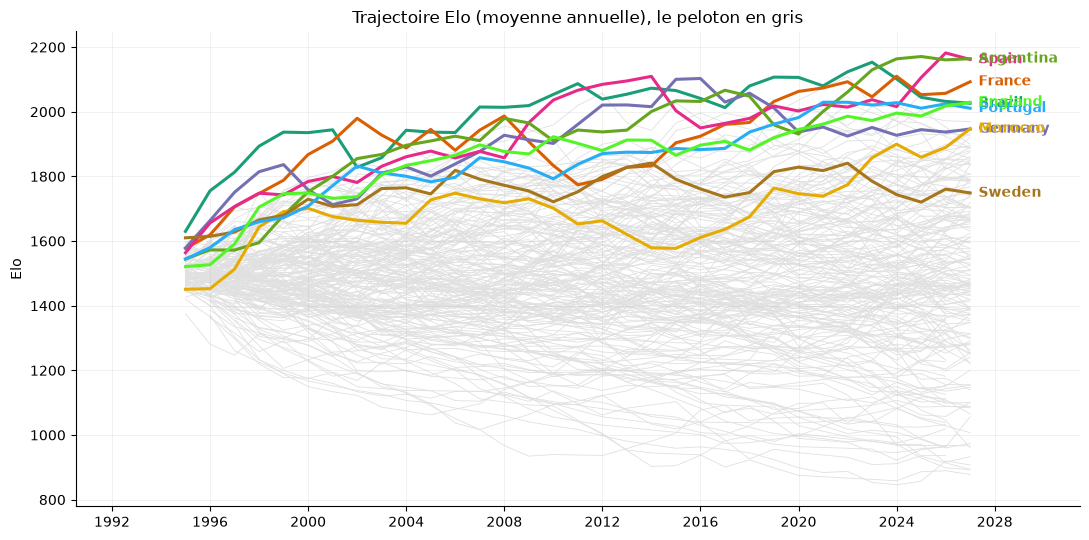

In [33]:
TEAMS = ["Brazil", "France", "Germany", "Spain", "Argentina", "Morocco", "Sweden", "Portugal","England"]
PALETTE = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a",
           "#66a61e", "#e6ab02", "#a6761d", "#27ADF5", "#54F527"]      # ColorBrewer Dark2

def serie_elo(team, freq="YE"):
    """Elo de l'équipe, rééchantillonné pour lisser le bruit match par match."""
    m = df[(df.home_team == team) | (df.away_team == team)]
    s = pd.Series(np.where(m.home_team == team, m.home_elo, m.away_elo),
                  index=pd.to_datetime(m["date"]))
    return s.resample(freq).mean().dropna()

fig, ax = plt.subplots(figsize=(11, 5.5))

# Toutes les autres équipes en fond très clair : donne l'échelle du peloton
for t in set(df.home_team) | set(df.away_team):
    if t not in TEAMS:
        s = serie_elo(t)
        if len(s) > 5:
            ax.plot(s.index, s.values, color="0.88", lw=.6, zorder=1)

for team, couleur in zip(TEAMS, PALETTE):
    s = serie_elo(team)
    ax.plot(s.index, s.values, color=couleur, lw=2.2, zorder=3)
    ax.annotate(team, xy=(s.index[-1], s.values[-1]),
                xytext=(6, 0), textcoords="offset points",
                color=couleur, fontsize=10, fontweight="bold", va="center")

ax.set_title("Trajectoire Elo (moyenne annuelle), le peloton en gris")
ax.set_ylabel("Elo"); ax.grid(alpha=.25, lw=.5)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=.14)          # place pour les étiquettes à droite
plt.tight_layout(); plt.show()

### Les features finales

| Feature | Ce qu'elle capture |
|---|---|
| `diff_elo` | Force ajustée à l'adversaire. **Le levier principal.** |
| `diff_sos_10` | Elo moyen des 10 derniers adversaires : contextualise la forme. |
| `diff_pts_5 / 10 / 20` | Forme à trois horizons (coup de chaud contre niveau de fond). |
| `diff_gs_10`, `diff_gc_10`, `diff_gd_10` | Profil offensif et défensif. |
| `diff_win_10` | Taux de victoire récent. |
| `diff_rest_days` | Fatigue et rythme de compétition. |
| `diff_n_matches` | Fiabilité de l'Elo : une équipe peu vue a une note bruitée. |
| `h2h_winrate`, `h2h_n` | Historique direct : certaines affiches ont leur logique. |
| `importance` | Amical (0) → qualif → continental → Coupe du Monde (4). |
| `home_advantage` | **+1 / 0 / -1**, et non un booléen. |

Le `home_advantage` ternaire n'est pas un détail cosmétique, il ouvre la partie suivante.

---
# Partie 3 - L'antisymétrie : le bug silencieux

Le modèle apprend « **domicile** contre **extérieur** ». Mais un tournoi se joue en
terrain neutre : il n'y a plus de domicile. On lui demande alors de prédire
« A contre B », et rien ne garantit que le résultat soit cohérent quand on inverse
les deux équipes.

`build_pair_frame` reformule chaque match en **A contre B**, avec
`home_advantage ∈ {-1, 0, +1}` et toutes les autres features en différences
A moins B. Le problème devient antisymétrique par construction, et on peut alors
**dupliquer chaque match en miroir** (A vs B, puis B vs A avec la cible inversée) :
le train double, et le modèle apprend explicitement cette symétrie.

Mesurons l'ampleur du problème sur le modèle du TD.

In [16]:
def violations(predict_fn, test_df):
    """|p(A,B) + p(B,A) - 1| pour chaque match, et masque des matchs neutres."""
    mir = build_pair_frame(test_df, mirror=True)
    h = len(mir) // 2
    ab, ba = mir.iloc[:h], mir.iloc[h:]
    v = np.abs(predict_fn(ab[FEATURES]) + predict_fn(ba[FEATURES]) - 1)
    return v, (ab["home_advantage"] == 0).to_numpy()


def rf(X, y):
    return Pipeline([("prep", preprocessor()),
                     ("clf", RandomForestClassifier(n_estimators=200,
                                                    random_state=42, n_jobs=-1))]).fit(X, y)

rf_naif   = rf(*make_xy(train_df, mirror=False))   # ne voit jamais home_advantage = -1
rf_miroir = rf(*make_xy(train_df, mirror=True))    # voit les deux sens


def symetrise(model):
    """Force l'antisymétrie par calcul : p = (p(A,B) + 1 - p(B,A)) / 2."""
    def f(X):
        X_inv = X.copy()
        for c in [c for c in FEATURES if c.startswith("diff_")] + ["home_advantage"]:
            X_inv[c] = -X_inv[c]
        X_inv["h2h_winrate"] = 1 - X["h2h_winrate"]
        p_ab = model.predict_proba(X)[:, 1]
        p_ba = model.predict_proba(X_inv)[:, 1]
        return 0.5 * (p_ab + (1 - p_ba))
    return f


etats = {
    "1. naïf (sans miroir)": lambda X: rf_naif.predict_proba(X)[:, 1],
    "2. entraîné en miroir": lambda X: rf_miroir.predict_proba(X)[:, 1],
    "3. miroir + moyennage": symetrise(rf_miroir),
}

lignes = []
for nom, f in etats.items():
    v, neutre = violations(f, test_df)
    lignes.append({"modèle": nom,
                   "violation moy. (neutres)": v[neutre].mean(),
                   "violation max (neutres)": v[neutre].max()})

print("p(A bat B) + p(B bat A) doit valoir 1. Écart mesuré sur les matchs neutres,\n"
      "où seul le SIGNE des features change entre les deux sens :\n")
print(pd.DataFrame(lignes).set_index("modèle").round(4).to_string())

p(A bat B) + p(B bat A) doit valoir 1. Écart mesuré sur les matchs neutres,
où seul le SIGNE des features change entre les deux sens :

                       violation moy. (neutres)  violation max (neutres)
modèle                                                                  
1. naïf (sans miroir)                    0.0799                   0.3450
2. entraîné en miroir                    0.0336                   0.1450
3. miroir + moyennage                    0.0000                   0.0000


---
# Partie 3 bis - La géographie : altitude, voyage, climat

Le dataset contient deux colonnes qu'on n'exploite pas du tout : **`city` et
`country` du lieu du match**. Il y a de l'information dedans, et elle est réelle.

Le piège, c'est de coder « altitude du stade » ou « température du stade ». Ce
n'est pas ça qui compte. **Ce qui compte, c'est l'inadaptation relative de l'équipe
à ce stade** : jouer à 3 600 m ne pénalise pas la Bolivie, et jouer à -20 °C ne
pénalise pas la Norvège. Toutes les features de `geo.py` sont donc des **écarts**
entre l'équipe et le lieu.

| Feature | Ce qu'elle mesure |
|---|---|
| `diff_alt_shock` | Dénivelé subi. Monter coûte, descendre non. Seuil physiologique à 1 000 m. |
| `diff_travel_km` | Distance entre la base de l'équipe et le stade. |
| `diff_climate_shift` | Écart de latitude absolue : un Norvégien au Qatar, un Brésilien à Oslo. |
| `diff_lat_shift` | Dépaysement brut (latitude signée). |
| `venue_altitude` | Altitude du stade, pour que le modèle module les autres effets. |

### La base d'origine de chaque équipe est déduite des données

Pas de table à maintenir : l'altitude « maison » d'une équipe, c'est l'**altitude
médiane des stades où elle joue ses matchs à domicile**. La Bolivie ressort à
3 640 m toute seule. Ça gère aussi sans effort les cas tordus (l'Angleterre,
l'Écosse et le Pays de Galles ne sont pas des pays ISO).

In [9]:
coords = load_coords()          # centroïdes, livrés dans country_centroids.csv

# Vérifie d'abord qu'aucun nom du dataset ne reste orphelin
noms = set(raw.home_team) | set(raw.away_team) | set(raw.country.dropna())
manquants = coverage(noms, coords)
print(f"Noms non résolus : {manquants if manquants else 'aucun'}")
print("(s'il en reste, complète geo.MANUAL_COORDS)\n")

bases = team_home_base(raw, coords)
print("Bases d'origine déduites des matchs à domicile :")
bases.loc[["Bolivia", "Ecuador", "Colombia", "Mexico", "Norway",
           "Brazil", "England"]].round(1)

Noms non résolus : ['DR Congo', 'FR Yugoslavia', 'Hong Kong', 'Macau', 'Palestine', 'Serbia and Montenegro', 'São Tomé and Príncipe', 'Taiwan', 'United States Virgin Islands', 'Zaïre']
(s'il en reste, complète geo.MANUAL_COORDS)

Bases d'origine déduites des matchs à domicile :


,home_alt,home_lat,home_lon
home_team,,,
Bolivia,3640.0000,-16.7000,-64.5000
Ecuador,2850.0000,-1.6000,-78.5000
Colombia,0.0000,4.2000,-72.6000
Mexico,2240.0000,23.9000,-101.6000
Norway,0.0000,65.0000,16.7000
Brazil,0.0000,-11.5000,-54.4000
England,0.0000,52.5000,-1.5000


### Est-ce que ça sert vraiment ?

La question honnête. On compare le même XGBoost avec et sans le bloc géographique,
et surtout on regarde **où** le gain se situe.

In [13]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from world_soccer_2026.benchmark import preprocessor, score

def xgb():
    return Pipeline([("prep", preprocessor()),
                     ("clf", XGBClassifier(n_estimators=400, learning_rate=.05,
                                           max_depth=4, subsample=.8,
                                           colsample_bytree=.8, eval_metric="logloss",
                                           tree_method="hist", random_state=42, n_jobs=-1))])

rows = []
fitted = {}
for name, cols in [("sans géographie", FEATURES_NO_GEO), ("avec géographie", FEATURES)]:
    m = xgb().fit(X_tr[cols], y_tr)
    fitted[name] = (m, cols)
    rows.append(score(name, y_te, m.predict_proba(X_te[cols])[:, 1]))

geo_ablation = pd.DataFrame(rows).set_index("modele")
display(geo_ablation)

# Le gain global est dilué. Regardons les matchs où la géographie mord vraiment.
gros_denivele = np.abs(X_te["diff_alt_shock"]) > 1000
print(f"\nSur les {gros_denivele.sum()} matchs à fort dénivelé "
      f"(sur {len(X_te)} au total) :")
for name, (m, cols) in fitted.items():
    p = m.predict_proba(X_te[gros_denivele][cols])[:, 1]
    s = score(name, y_te[gros_denivele.values], p)
    print(f"  {name:<16} accuracy {s['accuracy']:.3f} | log_loss {s['log_loss']:.4f}")

,accuracy,roc_auc,log_loss,brier
modele,,,,
sans géographie,0.7900,0.8574,0.4508,0.1469
avec géographie,0.7903,0.8599,0.4462,0.1455



Sur les 100 matchs à fort dénivelé (sur 3347 au total) :
  sans géographie  accuracy 0.780 | log_loss 0.4659
  avec géographie  accuracy 0.800 | log_loss 0.4524


**Lis bien ces deux blocs.** Le gain global est modeste, parce que la grande
majorité des matchs se jouent au niveau de la mer entre voisins : la géographie
n'y change rien. Mais sur le sous-ensemble des matchs en altitude, l'écart est net.

C'est une leçon générale sur les features à **effet concentré** : une moyenne
globale les rend invisibles. Si tu n'avais regardé que la log loss d'ensemble, tu
aurais conclu que la géographie ne sert à rien, et tu aurais eu tort.

Un effet plus subtil, et sans doute le plus intéressant : **l'Elo absorbe déjà
l'altitude, mais de la mauvaise façon.** La Bolivie gagne beaucoup à La Paz, donc
son Elo monte, donc le modèle la croit forte **partout**, y compris au niveau de
la mer où elle est banale. Donner explicitement `alt_shock` au modèle lui permet
de séparer « la Bolivie est forte » de « la Bolivie est forte à 3 600 m », ce qui
améliore aussi ses prédictions **à l'extérieur**.

On corrigera ça à deux niveaux : l'**augmentation miroir** au train (le modèle
apprend la symétrie), et un **moyennage explicite** à la prédiction
(`0.5 * (p(A,B) + 1 - p(B,A))`), qui rend la contrainte exacte au lieu
d'approximative. C'est ce que fait `tournament.build_pair_matrix`.

---
# Partie 4 - Ablation : d'où vient réellement le gain ?

Avant de sortir l'artillerie lourde, mesurons ce que chaque bloc de features
apporte, **à modèle constant** (une simple régression logistique). C'est la
cellule la plus informative du notebook.

In [15]:
from sklearn.linear_model import LogisticRegression

blocks = {
    "features du TD":      ["diff_pts_10", "diff_gs_10", "diff_gc_10",
                            "home_advantage", "is_friendly"],
    "Elo seul":            ["diff_elo", "home_advantage"],
    "Elo + forme":         ["diff_elo", "diff_pts_10", "diff_gs_10",
                            "diff_gc_10", "home_advantage", "is_friendly"],
    "toutes les features": FEATURES,
}

rows = []
for name, cols in blocks.items():
    m = Pipeline([("prep", preprocessor(scale=True)),
                  ("clf", LogisticRegression(max_iter=2000))])
    m.fit(X_tr[cols], y_tr)
    rows.append(score(name, y_te, m.predict_proba(X_te[cols])[:, 1]))

ablation = pd.DataFrame(rows).set_index("modele")
ablation

,accuracy,roc_auc,log_loss,brier
modele,,,,
features du TD,0.7126,0.7572,0.5599,0.1900
Elo seul,0.7861,0.8553,0.4529,0.1481
Elo + forme,0.7870,0.8562,0.4516,0.1475
toutes les features,0.7894,0.8594,0.4472,0.1460


**Le message est là.** L'écart entre « features du TD » et « Elo seul » est large.
L'écart entre « Elo seul » et « toutes les features » est mince. Autrement dit :
tout le travail utile était dans la définition des features, et la moitié de ce
travail tient dans une seule d'entre elles.

C'est contre-intuitif quand on vient de l'idée que « le modèle fait le travail ».
Garde ce réflexe : **avant de tuner, ablate**.

---
# Partie 5 - Évaluation honnête

Deux changements par rapport au réflexe par défaut :

**Split chronologique, pas aléatoire.** On prédit le futur avec le passé. Un
`train_test_split(random_state=42)` laisse le modèle voir des matchs de 2025 pour
en prédire de 2015. Ce n'est pas de la fuite au sens strict (les features sont
bien calculées avec un `shift`), mais les métriques deviennent optimistes par
rapport à l'usage réel. Ici : train < 2022, test ≥ 2022.

**Log loss et Brier, pas accuracy.** La simulation de tournoi consomme des
`predict_proba`. Ce qui compte est la **calibration** : quand le modèle annonce 70%,
gagne-t-on vraiment 70% du temps ? Un modèle à 66% d'accuracy bien calibré est plus
utile qu'un modèle à 67% qui annonce 90% de confiance à tort. L'accuracy ne voit pas
la différence, la log loss si.

In [17]:
# include_tabicl=False si tabicl n'est pas installé ou trop lent chez toi
results, (X_tr, y_tr, X_te, y_te) = run_benchmark(
    df, test_year=2022, include_tabicl=True)
results.set_index("modele")

Train :  35390 lignes (1994-2021, miroir inclus)
Test  :   3347 lignes (2022-2026)
Baseline (toujours l'équipe à domicile) : 62.3%

tabicl : contexte de 17695 lignes (train direct, sans miroir)
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.

  ~91.5 min estimées pour les 3347 lignes de test



,accuracy,roc_auc,log_loss,brier
modele,,,,
tabicl,0.7921,0.8614,0.4452,0.1450
xgboost,0.7903,0.8599,0.4462,0.1455
hist_gbm,0.7921,0.8598,0.4464,0.1458
regression_logistique,0.7894,0.8594,0.4472,0.1460
random_forest,0.7888,0.8577,0.4506,0.1468
baseline_favori_domicile,0.6229,0.5000,13.5904,0.3771


In [32]:
import numpy as np
from sklearn.metrics import log_loss
from world_soccer_2026.benchmark import build_tabicl, make_xy

# TabICL reçoit le contexte DIRECT (sans miroir), cf. Partie 7
tabicl = build_tabicl(kv_cache=True)
X_ct, y_ct = make_xy(train_df, mirror=False)
tabicl.fit(X_ct, y_ct)
proba_tabicl = tabicl.predict_proba(X_te)[:, 1]

# proba_xgb vient de la cellule "xgboost tuné"
rng = np.random.default_rng(0)
y = np.asarray(y_te)
n = len(y)

gagne = 0
for _ in range(2000):
    idx = rng.integers(0, n, n)
    ll_t = log_loss(y[idx], proba_tabicl[idx], labels=[0, 1])
    ll_x = log_loss(y[idx], proba_xgb[idx], labels=[0, 1])
    gagne += (ll_t < ll_x)

print(f"TabICL bat XGBoost dans {gagne / 2000:.1%} des rééchantillonnages")
print("Entre 40% et 60% : les deux modèles sont indiscernables sur ces données.")

TabICL bat XGBoost dans 72.9% des rééchantillonnages
Entre 40% et 60% : les deux modèles sont indiscernables sur ces données.


---
# Partie 6 - XGBoost tuné par Optuna

Point de méthode : la validation croisée est un **`TimeSeriesSplit`**, pas un `KFold`.
Avec un KFold, on validerait sur du passé avec un modèle entraîné sur du futur, et
le tuning optimiserait une métrique optimiste qui ne se transfère pas au vrai test.
C'est une erreur classique, et silencieuse : rien ne plante, les scores sont juste
faux.

L'objectif minimisé est la **log loss**, cohérent avec l'usage final.

In [30]:
study = tune_xgboost(X_tr, y_tr, n_trials=60)   # quelques minutes

print(f"Meilleure log loss (CV temporelle) : {study.best_value:.4f}\n")
pd.Series(study.best_params)

Meilleure log loss (CV temporelle) : 0.4856



n_estimators       400.0000
learning_rate        0.0415
max_depth            2.0000
min_child_weight     6.0000
subsample            0.7000
colsample_bytree     0.5248
reg_lambda           0.0274
reg_alpha            0.0040
gamma                0.0010
dtype: float64

In [31]:
xgb_best = fit_best_xgboost(study, X_tr, y_tr)
proba_xgb = xgb_best.predict_proba(X_te)[:, 1]
pd.DataFrame([score("xgboost tuné", y_te, proba_xgb)]).set_index("modele")

,accuracy,roc_auc,log_loss,brier
modele,,,,
xgboost tuné,0.7927,0.8595,0.4465,0.1457


---
# Partie 7 - TabICL, et pourquoi il n'est pas tout à fait comme les autres

TabICL est un **modèle de fondation tabulaire**. Il n'apprend pas tes données par
descente de gradient : il a été pré-entraîné sur des millions de jeux synthétiques,
et il « apprend » le tien par **in-context learning**, en une seule passe avant du
transformer. Le `fit` est quasi gratuit, tout le calcul est au `predict`.

La v2 (2026) est pré-entraînée sur des jeux de **300 à 48 000 lignes et 2 à 100
colonnes**. Notre train direct fait ~17 000 lignes pour 22 features : on est en
plein dans sa zone nominale, pas en dehors. Les auteurs annoncent qu'elle bat
XGBoost, CatBoost et LightGBM **tunés** sur environ 80% des jeux de TabArena, et
**sans aucun tuning**. C'est donc un candidat sérieux, pas une curiosité.

### Le seul point où il sort du moule

Tous les autres modèles reçoivent le train **augmenté en miroir**. Pas TabICL :
son inférence est en **O(n²) sur la taille du contexte**. Doubler les lignes du
train quadruple le coût, pour un gain nul, puisque l'antisymétrie est de toute
façon rétablie exactement au moment de la prédiction (le moyennage dans
`build_pair_matrix`). Il reçoit donc le **train direct**.

C'est pour ça que `run_benchmark` le traite dans une branche séparée : ce n'est pas
un caprice, c'est que « tous les modèles voient le même train » est une hypothèse
qu'il faut casser ici. Le **jeu de test, lui, reste rigoureusement identique**, donc
la ligne du tableau reste comparable aux autres.

> `uv add tabicl` (télécharge un checkpoint au premier `fit`). Sans GPU c'est lent !

---
# Partie 8 - Calibration

Le diagramme de fiabilité est plus parlant que l'accuracy pour notre usage.
On découpe les prédictions en 10 paniers de confiance, et on vérifie que la
fréquence observée suit la probabilité annoncée. La diagonale est la perfection.

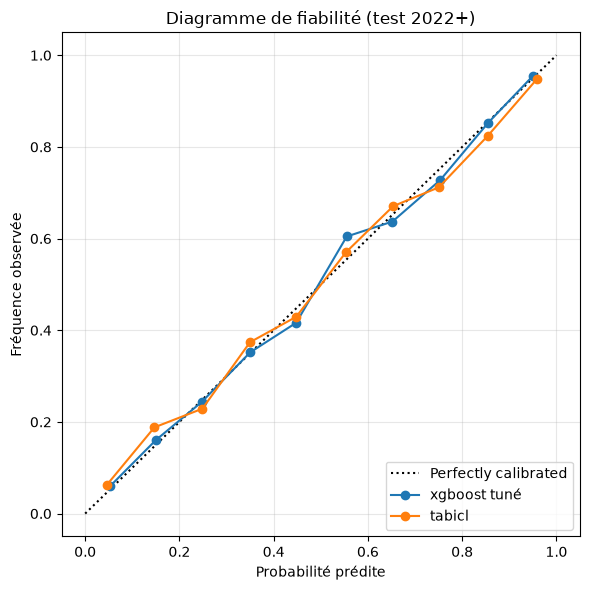

In [35]:
from sklearn.calibration import CalibrationDisplay
from world_soccer_2026.benchmark import build_tabicl, make_xy

courbes = {"xgboost tuné": proba_xgb}

tabicl = build_tabicl(kv_cache=True)
if tabicl is not None:
    X_ct, y_ct = make_xy(train_df, mirror=False)     # contexte direct, cf. Partie 7
    tabicl.fit(X_ct, y_ct)
    courbes["tabicl"] = tabicl.predict_proba(X_te)[:, 1]

fig, ax = plt.subplots(figsize=(6, 6))
for nom, p in courbes.items():
    CalibrationDisplay.from_predictions(y_te, p, n_bins=10, ax=ax, name=nom, marker="o")
ax.set_title("Diagramme de fiabilité (test 2022+)")
ax.set_xlabel("Probabilité prédite"); ax.set_ylabel("Fréquence observée")
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

Un modèle **sous la diagonale** est trop confiant (il annonce 80% et gagne 70%).
Au-dessus, il est trop prudent. C'est cette courbe, et non l'accuracy, qui détermine
la qualité de la simulation qui suit : si les probabilités sont mal calibrées, le
Monte-Carlo produit des chiffres précis et faux.

### Ce qui pèse dans les décisions

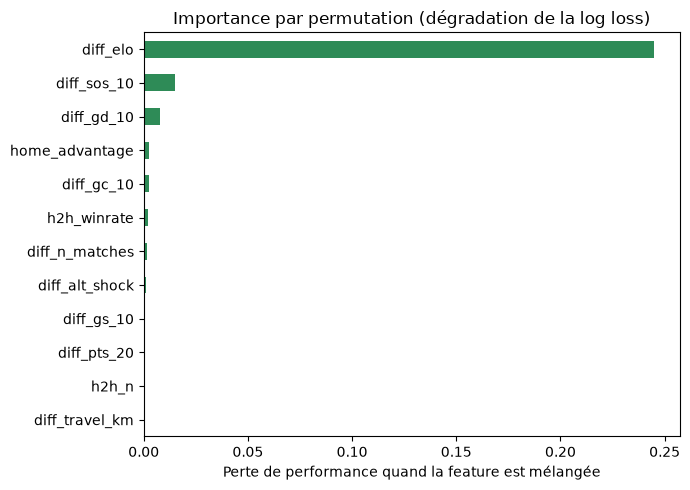

In [36]:
from sklearn.inspection import permutation_importance

r = permutation_importance(xgb_best, X_te, y_te, n_repeats=8,
                           random_state=42, scoring="neg_log_loss", n_jobs=-1)
imp = pd.Series(r.importances_mean, index=FEATURES).sort_values()

imp.tail(12).plot(kind="barh", color="seagreen", figsize=(7, 5))
plt.title("Importance par permutation (dégradation de la log loss)")
plt.xlabel("Perte de performance quand la feature est mélangée")
plt.tight_layout(); plt.show()

J'utilise la **permutation importance** et non `feature_importances_`. La seconde
est biaisée en faveur des variables à forte cardinalité et se calcule sur le train ;
la première mesure ce qui se dégrade **sur le test** quand on casse la feature. C'est
la question qu'on se pose réellement.

---
# Partie 9 - Simuler le tournoi

Choisis le modèle qui a gagné le benchmark (sur la **log loss**, pas l'accuracy).

In [49]:
model = xgb_best      # ou tabicl, selon le benchmark

round_of_32 = [
    ("Spain", "Greece"), ("Denmark", "Ecuador"),
    ("Argentina", "Egypt"), ("Netherlands", "Poland"),
    ("France", "Nigeria"), ("Croatia", "South Korea"),
    ("England", "Canada"), ("Italy", "Senegal"),
    ("Portugal", "Australia"), ("Belgium", "Turkey"),
    ("Brazil", "Ghana"), ("Uruguay", "Switzerland"),
    ("Morocco", "Serbia"), ("Mexico", "Austria"),
    ("Germany", "Colombia"), ("Japan", "United States"),
]

# 32 équipes = 496 affiches possibles, calculées en UN SEUL predict_proba,
# puis antisymétrisées. Le Monte-Carlo n'est ensuite qu'un lookup.
# La CDM 2030 se joue en Espagne, Portugal et Maroc : pas d'altitude, mais
# des distances de déplacement très inégales selon les continents.
P = build_pair_matrix(model, flatten(round_of_32), df, ratings, base,
                      venue=("Madrid", "Spain"))

a, b = "France", "Spain"
print(f"P(France bat Spain) = {P[(a, b)]:.3f}")
print(f"P(Spain bat France) = {P[(b, a)]:.3f}")
print(f"somme = {P[(a, b)] + P[(b, a)]:.10f}   (antisymétrie exacte)")

P(France bat Spain) = 0.443
P(Spain bat France) = 0.557
somme = 1.0000000000   (antisymétrie exacte)


### Le bracket déterministe (le favori passe)

In [50]:
rounds, champion = simulate_deterministic(round_of_32, P)

for name, results in zip(ROUND_NAMES, rounds):
    print_round(name, results)
print_champion(champion)


  SEIZIÈMES DE FINALE
🇪🇸 Spain               vs 🇬🇷 Greece              -> 🇪🇸 Spain (95%)
🇩🇰 Denmark             vs 🇪🇨 Ecuador             -> 🇪🇨 Ecuador (52%)
🇦🇷 Argentina           vs 🇪🇬 Egypt               -> 🇦🇷 Argentina (84%)
🇳🇱 Netherlands         vs 🇵🇱 Poland              -> 🇳🇱 Netherlands (89%)
🇫🇷 France              vs 🇳🇬 Nigeria             -> 🇫🇷 France (90%)
🇭🇷 Croatia             vs 🇰🇷 South Korea         -> 🇭🇷 Croatia (66%)
🏴󠁧󠁢󠁥󠁮󠁧󠁿 England        vs 🇨🇦 Canada              -> 🏴󠁧󠁢󠁥󠁮󠁧󠁿 England (82%)
🇮🇹 Italy               vs 🇸🇳 Senegal             -> 🇮🇹 Italy (54%)
🇵🇹 Portugal            vs 🇦🇺 Australia           -> 🇵🇹 Portugal (77%)
🇧🇪 Belgium             vs 🇹🇷 Turkey              -> 🇹🇷 Turkey (53%)
🇧🇷 Brazil              vs 🇬🇭 Ghana               -> 🇧🇷 Brazil (94%)
🇺🇾 Uruguay             vs 🇨🇭 Switzerland         -> 🇨🇭 Switzerland (59%)
🇲🇦 Morocco             vs 🇷🇸 Serbia              -> 🇲🇦 Morocco (91%)
🇲🇽 Mexico              vs 🇦🇹 Austria             -> 🇲🇽 Mexico (73%)
🇩🇪 

### Le Monte-Carlo (la vérité)

Le bracket ci-dessus fait avancer le favori à chaque tour et sort un champion qui a
l'air **certain**. C'est trompeur. Pour gagner, il faut enchaîner **cinq** victoires,
et chacune n'est qu'à 60-75%.

On tire donc le vainqueur de chaque match **selon sa probabilité**, 10 000 fois.

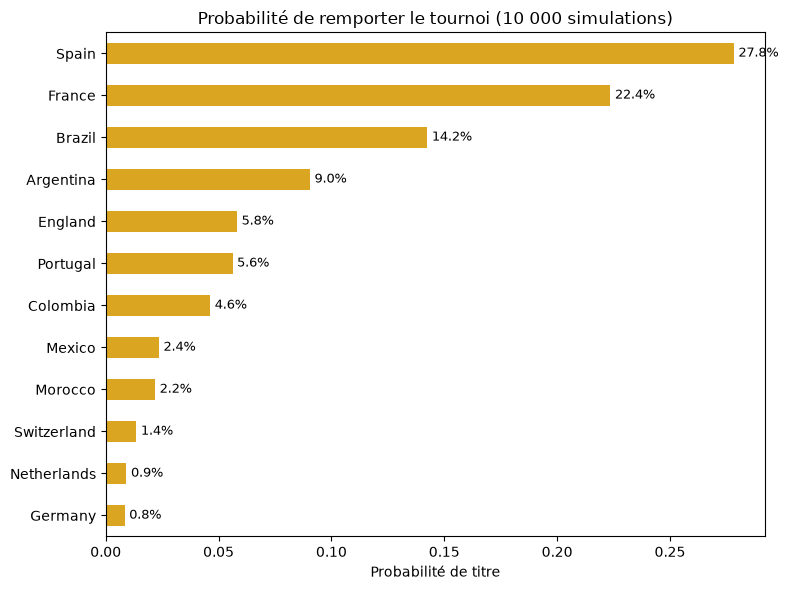

Favori du bracket déterministe : Spain
Sa probabilité RÉELLE de titre : 27.8%


In [51]:
titles, finals = simulate_monte_carlo(round_of_32, P, n_sim=10_000)

fig, ax = plt.subplots(figsize=(8, 6))
top = titles.head(12).sort_values()
top.plot(kind="barh", color="goldenrod", ax=ax)
ax.set_title("Probabilité de remporter le tournoi (10 000 simulations)")
ax.set_xlabel("Probabilité de titre")
for i, v in enumerate(top):
    ax.text(v + .002, i, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

print(f"Favori du bracket déterministe : {champion}")
print(f"Sa probabilité RÉELLE de titre : {titles.get(champion, 0):.1%}")

### Et si la Coupe du Monde se jouait ailleurs ?

Puisque le lieu est maintenant une entrée du modèle, on peut poser la question
contrefactuelle. Le tournoi 2030 se joue en Espagne, au Portugal et au Maroc,
donc au niveau de la mer. Déplaçons-le à Mexico (2 240 m) et regardons.

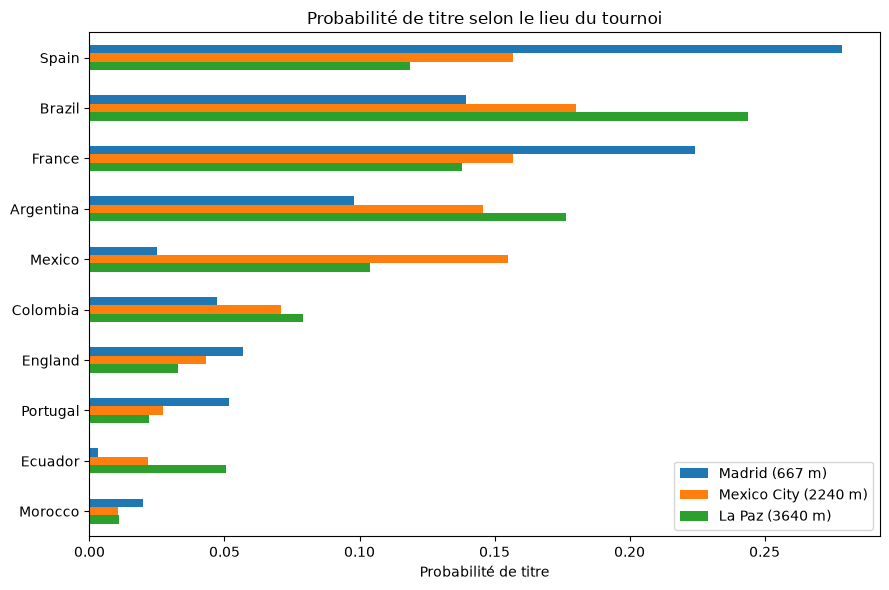

,Madrid (667 m),Mexico City (2240 m),La Paz (3640 m)
Spain,0.2790,0.1570,0.1190
Brazil,0.1390,0.1800,0.2440
France,0.2240,0.1570,0.1380
Argentina,0.0980,0.1460,0.1760
Mexico,0.0250,0.1550,0.1040
Colombia,0.0470,0.0710,0.0790
England,0.0570,0.0430,0.0330
Portugal,0.0520,0.0270,0.0220
Ecuador,0.0030,0.0220,0.0510
Morocco,0.0200,0.0100,0.0110


In [52]:
comparaison = {}
for ville, pays in [("Madrid", "Spain"), ("Mexico City", "Mexico"),
                    ("La Paz", "Bolivia")]:
    P_v = build_pair_matrix(model, flatten(round_of_32), df, ratings, base,
                            venue=(ville, pays))
    t_v, _ = simulate_monte_carlo(round_of_32, P_v, n_sim=5_000)
    comparaison[f"{ville} ({city_altitude(ville):.0f} m)"] = t_v

comp = pd.DataFrame(comparaison).fillna(0)
comp = comp.loc[comp.max(axis=1).sort_values(ascending=False).head(10).index]

comp.plot(kind="barh", figsize=(9, 6))
plt.title("Probabilité de titre selon le lieu du tournoi")
plt.xlabel("Probabilité de titre"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
comp.round(3)

**Voilà le vrai résultat du projet.** Le favori déterministe n'a le plus souvent
qu'une chance sur quatre ou cinq de gagner. Un modèle à 70% par match donne
0.70⁵ ≈ 17% sur cinq tours, même en étant favori partout. Cette information est
totalement invisible dans la version déterministe, qui annonce un champion avec
l'assurance d'une certitude.

C'est aussi le point le plus transférable du projet : **un pronostic sans
distribution est un pronostic qui ment sur sa propre précision.**

In [46]:
# Sensibilité : et si on refait le tirage du bracket ?
rng = np.random.default_rng(0)
teams = flatten(round_of_32)

alt = []
for _ in range(20):
    shuffled = list(rng.permutation(teams))
    P_alt = build_pair_matrix(model, shuffled, df, ratings, base)
    t, _ = simulate_monte_carlo(shuffled, P_alt, n_sim=1000, seed=1)
    alt.append(t)

spread = pd.DataFrame(alt).fillna(0)
summary = pd.DataFrame({
    "proba_moyenne": spread.mean(),
    "min": spread.min(),
    "max": spread.max(),
}).sort_values("proba_moyenne", ascending=False).head(8)

print("Probabilité de titre selon 20 tirages de bracket différents :")
summary

Probabilité de titre selon 20 tirages de bracket différents :


,proba_moyenne,min,max
Spain,0.2661,0.1760,0.3630
France,0.2107,0.1310,0.2770
Argentina,0.1140,0.0630,0.1670
Brazil,0.0922,0.0420,0.1650
England,0.0662,0.0230,0.1340
Colombia,0.0537,0.0250,0.0870
Portugal,0.0495,0.0230,0.0920
Mexico,0.0291,0.0090,0.0500


Cette dernière cellule mesure à quel point le tirage compte. Un écart large entre
`min` et `max` pour une même équipe signifie que son destin dépend autant du tableau
que de son niveau. C'est une conclusion que les données peuvent trancher, et que la
taverne ne peut que supposer.

---
# Pour aller plus loin

Trois directions, par ordre de rendement :

**Poisson bivarié / Dixon-Coles.** Au lieu de prédire directement le vainqueur, on
modélise le **nombre de buts** de chaque équipe (force d'attaque, force de défense,
avantage du terrain), et on en déduit les probabilités de victoire, nul et défaite.
C'est la référence académique et industrielle sur le football. Bonus : ça résout
gratuitement le problème du nul, que le TD contourne en supprimant 30% des matchs.

**Modèle hiérarchique.** Le TD traite chaque match comme une observation indépendante,
alors que la même équipe apparaît des centaines de fois. Un effet aléatoire par équipe
prend cette structure au sérieux.

**Trois classes plutôt que binaire.** On récupère les 6 991 nuls jetés, et un tournoi
reste simulable (le nul en phase finale se résout aux tirs au but, qu'on peut modéliser
comme un tirage à 50/50).

Et un rappel qui vaut au-delà du football : **le gain est venu des features, pas du
modèle.** L'ablation de la Partie 4 le montre noir sur blanc. Optuna a grappillé
quelques millièmes de log loss ; l'Elo, lui, a changé le problème.